|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">A deep understanding of deep learning</a></h1>|
|-|:-:|
|<h2>Section:</h2>|<h1>Understand and design CNNs<h1>|
|<h2>Lecture:</h2>|<h1><b>Do autoencoders clean Gaussians?<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">udemy.com/course/deeplearning_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
# import libraries
import numpy as np

import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

# model summary info
from torchsummary import summary

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [2]:
# Idenitfy device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# Create Gaussian blurs with varying widths and occluding bars

In [3]:
def generate_gauss_data(imgSize:int, nGauss:int, normalize_pixels:bool=False):
  x = np.linspace(-4,4,imgSize)
  X,Y = np.meshgrid(x,x)

  # vary the weights smoothly
  widths = np.linspace(2,20,nGauss)

  # initialize tensor containing images
  images = torch.zeros(nGauss,1,imgSize,imgSize)  # non-occluded images
  images_occluded = torch.zeros(nGauss,1,imgSize,imgSize)  # occluded images

  for i in range(nGauss):

    # create the gaussian with random centers
    ro = 1.5*np.random.randn(2) # ro = random offset
    G  = np.exp( -( (X-ro[0])**2 + (Y-ro[1])**2) / widths[i] )

    # and add noise
    G  = G + np.random.randn(imgSize,imgSize)/5
    G_occluded = copy.deepcopy(G)

    # add a random bar randomly
    i1 = 13 # np.random.choice(np.arange(2,28))
    i2 = 4  # np.random.choice(np.arange(2,6))
    if np.random.randn()>0:
      G_occluded[i1:i1+i2,] = 1
    else:
      G_occluded[:,i1:i1+i2] = 1
      
    # Normalize the image to be between 0 and 1 (use min-max normalization)
    min_max_normalize = lambda x: (x - np.min(x)) / (np.max(x) - np.min(x))
    if normalize_pixels:
      G = min_max_normalize(G)
      G_occluded = min_max_normalize(G_occluded)

    # add to the tensor
    images[i,:,:,:] = torch.Tensor(G).view(1,imgSize,imgSize)
    images_occluded[i,:,:,:] = torch.Tensor(G_occluded).view(1,imgSize,imgSize)
    
  return copy.deepcopy(images), copy.deepcopy(images_occluded)

imgSize = 91  # image size
num_samples  = 10*1000
train_amount = 0.9
train_test_sizes = [int(train_amount*num_samples), int((1-train_amount)*num_samples)]
nGauss = train_test_sizes[0]
images, images_occluded = generate_gauss_data(imgSize, train_test_sizes[0])
test_images, test_images_occluded = generate_gauss_data(imgSize, train_test_sizes[1])

print('Training images size:', images.shape)
print('Training occluded images size:', images_occluded.shape)
print('Test images size:', test_images.shape)
print('Test occluded images size:', test_images_occluded.shape)

Training images size: torch.Size([9000, 1, 91, 91])
Training occluded images size: torch.Size([9000, 1, 91, 91])
Test images size: torch.Size([999, 1, 91, 91])
Test occluded images size: torch.Size([999, 1, 91, 91])


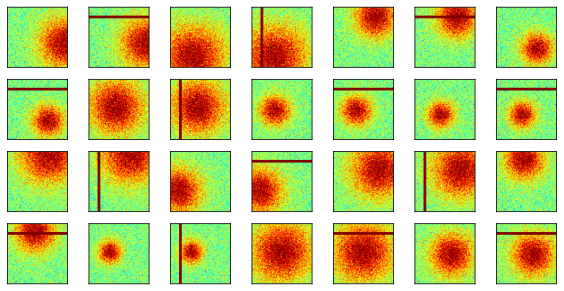

In [4]:
# visualize some images
fig,axs = plt.subplots(4,7,figsize=(10,5))

for i in range(0,len(axs.flatten())-1,2):
  whichpic = np.random.randint(nGauss)
  G = np.squeeze( images[whichpic,:,:].numpy() )
  G_occluded = np.squeeze( images_occluded[whichpic,:,:].numpy() )
  axs.flatten()[i].imshow(G,vmin=-1,vmax=1,cmap='jet')
  axs.flatten()[i+1].imshow(G_occluded,vmin=-1,vmax=1,cmap='jet')
  
for ax in axs.flatten():
  ax.set_xticks([])
  ax.set_yticks([])

plt.show()

# Create the DL model

In [5]:
# create a class for the model
def makeTheNet(lr:float=.001):

  class gausnet(nn.Module):
    def __init__(self):
      super().__init__()

      # encoding layer
      kpool_sz = (2,2)
      kernel_sz = 3
      padding = 1
      nUnits = 16
      self.enc = nn.Sequential(
          nn.Conv2d(1,nUnits,kernel_sz,padding=padding),
          # nn.BatchNorm2d(nUnits),
          nn.ReLU(),
          nn.AvgPool2d(kpool_sz),
          nn.Conv2d(nUnits,nUnits//2,kernel_sz,padding=padding),
          # nn.BatchNorm2d(nUnits//2),
          nn.ReLU(),
          nn.AvgPool2d(kpool_sz),
        )

      # decoding layer
      stride = 2
      self.dec = nn.Sequential(
          nn.ConvTranspose2d(nUnits//2,nUnits,kernel_sz,stride=stride),
          # nn.BatchNorm2d(nUnits),
          nn.ReLU(),
          nn.ConvTranspose2d(nUnits,1,kernel_sz,stride=stride),
          # nn.BatchNorm2d(1),
          # nn.Sigmoid(),
        )

    def forward(self,x):
      return self.dec( self.enc(x) )

  # create the model instance
  net = gausnet()

  # loss function
  lossfun = nn.MSELoss()
  # lossfun = nn.BCELoss()

  # optimizer
  optimizer = torch.optim.Adam(net.parameters(),lr=lr)

  return net,lossfun,optimizer

 
torch.Size([10, 1, 91, 91]) torch.Size([10, 1, 91, 91])


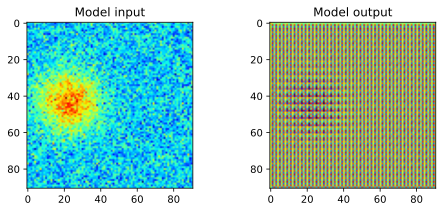

In [6]:
# test the model with one batch
net,lossfun,optimizer = makeTheNet()
X = images[:10,:,:,:]
yHat = net(X)

# check size of output
print(' ')
print(X.shape, yHat.shape)

# let's see how they look
fig,ax = plt.subplots(1,2,figsize=(8,3))
ax[0].imshow(torch.squeeze(X[0,0,:,:]).detach(),cmap='jet')
ax[0].set_title('Model input')
ax[1].imshow(torch.squeeze(yHat[0,0,:,:]).detach(),cmap='jet')
ax[1].set_title('Model output')

plt.show()

assert yHat.shape == X.shape, "Output shape is not the same as input shape!"

In [7]:
# count the total number of parameters in the model
summary(net,(1,imgSize,imgSize), device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 91, 91]             160
              ReLU-2           [-1, 16, 91, 91]               0
         AvgPool2d-3           [-1, 16, 45, 45]               0
            Conv2d-4            [-1, 8, 45, 45]           1,160
              ReLU-5            [-1, 8, 45, 45]               0
         AvgPool2d-6            [-1, 8, 22, 22]               0
   ConvTranspose2d-7           [-1, 16, 45, 45]           1,168
              ReLU-8           [-1, 16, 45, 45]               0
   ConvTranspose2d-9            [-1, 1, 91, 91]             145
Total params: 2,633
Trainable params: 2,633
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.03
Forward/backward pass size (MB): 3.10
Params size (MB): 0.01
Estimated Total Size (MB): 3.14
-----------------------------------------------

# Create a function that trains the model

In [8]:
# a function that trains the model
def function2trainTheModel(images, images_occluded, test_images, test_images_occluded, device, numepochs:int=500, lr:float=.001, batch_size:int=32):
  assert images.shape == images_occluded.shape, "Input images and occluded images must have the same shape!"
  assert test_images.shape == test_images_occluded.shape, "Test images and occluded test images must have the same shape!"
  
  # create a new model
  net,lossfun,optimizer = makeTheNet(lr=lr)
  net.to(device)
  
  X_test = test_images.to(device)
  X_test_occluded = test_images_occluded.to(device)

  # initialize losses
  losses = torch.zeros(numepochs)
  test_loss = torch.zeros(numepochs)
  
  # Create permutation index of images to use
  nGauss = images.shape[0]
  permutation = np.random.permutation(nGauss)
  
  # Ensure there are numepochs*batch_size permuted indexes
  permutation = np.tile(permutation, int(np.ceil((numepochs*batch_size)/nGauss)))[:numepochs*batch_size]
  np.random.shuffle(permutation)
  
  # loop over epochs
  for epochi in range(numepochs):
    print(f'Epoch {epochi+1}/{numepochs}   Train Loss: {losses[epochi]:.6f}   Test Loss: {test_loss[epochi]:.6f}', end='\r') if epochi % 100 != 0 else None
    net.train()

    # pick a set of images at random
    pics2use = permutation[epochi*batch_size:(epochi+1)*batch_size]
    X = images[pics2use,:,:,:].to(device)
    X_occluded = images_occluded[pics2use,:,:,:].to(device)

    # forward pass and loss
    yHat = net(X_occluded)
    loss = lossfun(yHat, X)
    losses[epochi] = loss.cpu().item()

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Evaluarte on test data
    net.eval()
    with torch.no_grad():
      yHat = net( X_test_occluded )
      test_loss[epochi] = lossfun(yHat, X_test).cpu().item()

  # end epochs

  # function output
  
  return losses, test_loss, net

# Run the model and show the results!

In [9]:
# Train on non-occluded images:
batch_size = 32
numepochs = 2*500  # nGauss // batch_size  # number of images over batch size
print('Number of epochs:', numepochs)
lr = 0.001
losses, test_loss, net = function2trainTheModel(images, images_occluded, test_images, test_images_occluded,
                                                device, numepochs=numepochs, lr=lr, batch_size=batch_size)

Number of epochs: 1000


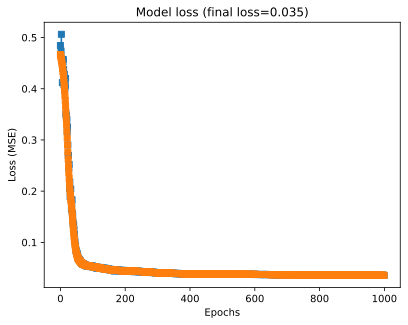

In [10]:
plt.figure()
plt.plot(losses,'s-',label='Train')
plt.plot(test_loss,'s-',label='Test')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Model loss (final loss=%.3f)'%losses[-1])
plt.show()

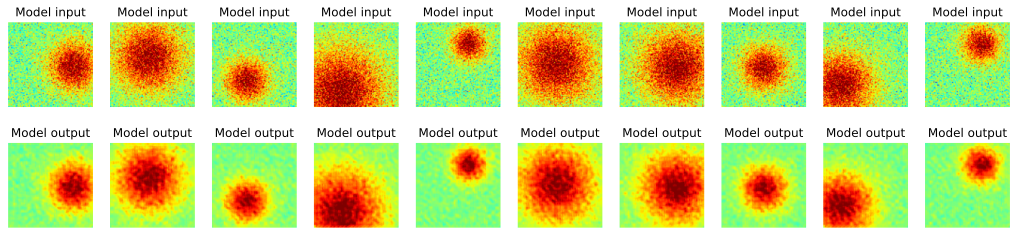

In [11]:
# visualize some images

pics2use = np.random.choice(nGauss,size=32,replace=False)
X = images[pics2use,:,:,:].to(device)
yHat = net(X)

fig,axs = plt.subplots(2,10,figsize=(18,4))

for i in range(10):

  G = torch.squeeze( X[i,0,:,:] ).cpu().detach()
  O = torch.squeeze( yHat[i,0,:,:] ).cpu().detach()

  axs[0,i].imshow(G,vmin=-1,vmax=1,cmap='jet')
  axs[0,i].axis('off')
  axs[0,i].set_title('Model input')

  axs[1,i].imshow(O,vmin=-1,vmax=1,cmap='jet')
  axs[1,i].axis('off')
  axs[1,i].set_title('Model output')

plt.show()

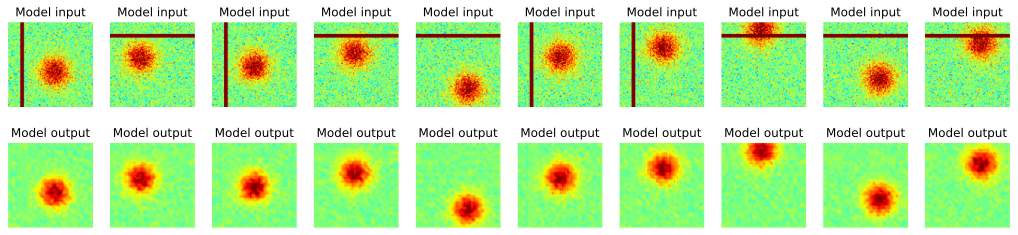

In [12]:
# Creatae a data-set with random occlusions and pass throug AE:
X_occluded = test_images_occluded.to(device)
yHat_occluded = net( X_occluded )

# Visualize some images randomly:
fig,axs = plt.subplots(2,10,figsize=(18,4))

for i in range(10):

  G = torch.squeeze( X_occluded[i,0,:,:] ).cpu().detach()
  O = torch.squeeze( yHat_occluded[i,0,:,:] ).cpu().detach()

  axs[0,i].imshow(G,vmin=-1,vmax=1,cmap='jet')
  axs[0,i].axis('off')
  axs[0,i].set_title('Model input')

  axs[1,i].imshow(O,vmin=-1,vmax=1,cmap='jet')
  axs[1,i].axis('off')
  axs[1,i].set_title('Model output')

plt.show()

# Additional explorations

In [13]:
# 1) The network does OK but there are still residual occlusion artifacts. Perhaps there weren't enough training examples?
#    If you would increase nGauss from 1000 to 10000, would that mean that the model trains on 10x as many examples?
#    (Hint: the answer is No, but you need to figure out why!) How can you adapt the model so that it trains on more
#    unique sample images?
# Answer: Increasing nGauss from 1000 to 10000 would not mean that the model trains on 10x as many unique examples.
#
# 2) The bars appear in a random location for each image. Would the network still learn to remove the occlusions if the
#    bars appeared in the exact same location with the same thickness? Change the stimulus generation code to implement
#    this. You can still keep the randomization to horizontal or vertical, but remove the random selection of thickness
#    and location.
# Answer: Yes.
#